# Temperature Forecasting with the Jena time series using PyTorch (AI4PH Course)

PyTorch translation of the companion notebook for Chapter 13 in *Deep Learning with Python, Third Edition*. F. Chollet and M. Watson.

The overall workflow, dataset, and experiments match the original notebook, but the implementation uses **PyTorch** instead of Keras.


In [1]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

In [2]:
'''
Importa las librerias necesarias, comprueba si cuda esta disponible
y muestra si se esta usando cpu o gpu
'''

import os
import copy
import math
import zipfile
import urllib.request

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Timeseries forecasting


### A temperature forecasting example


In [3]:
'''
Indica la url que contiene los datos y donde se van a almacenar en un zip y extrae los datos
'''
url = "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = "jena_climate_2009_2016.csv.zip"

urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(".")


In [4]:
'''
Asigna el path a una variable, abre el archivo y almacena los datos y el nombre en la cabecera. Muestra las cabeceras y la longitud de los datos
'''
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))


['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [ ]:
'''
Temperature es un array de longitud igual a lines, zeros. raw data un tensor de rango 2 con una longitud lineas y la otra header -1
'''
temperature = np.zeros((len(lines),), dtype="float32")
raw_data = np.zeros((len(lines), len(header) - 1), dtype="float32")

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]    #valores partiendo del 2 hasta el final que tienen un separador de coma
    temperature[i] = values[1]
    raw_data[i, :] = values[:]


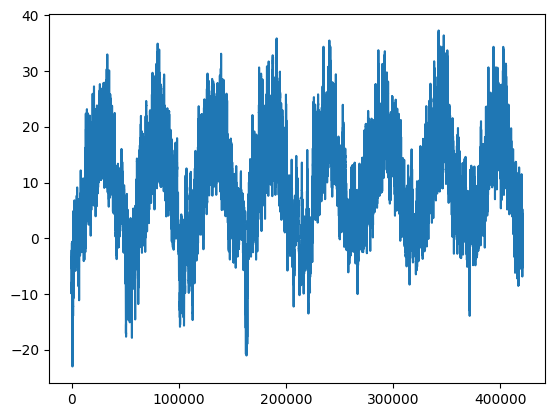

In [ ]:
plt.plot(range(len(temperature)), temperature)  #grafica de la temeperatura


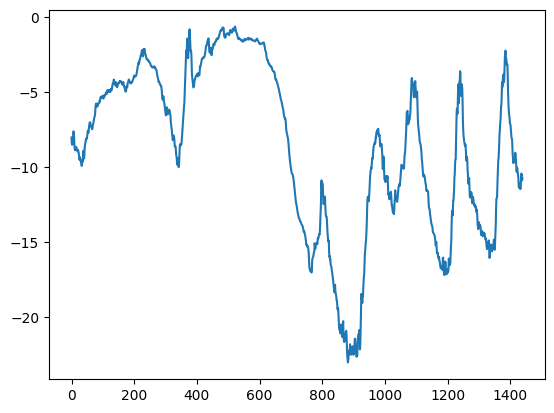

In [ ]:
plt.plot(range(1440), temperature[:1440])   #grafica de los primeros 1440 datos


In [ ]:
'''
Variables para la separacion en train test y validation. Train es la mitad del data set y validation el 0.25
'''

num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)


num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


#### Preparing the data


In [ ]:
'''
Realiza un preprocesado del train centrando en la media y dividiendo la desviacion tipica
'''

mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std


In [ ]:
'''
Crea una super clase que hereda de la clase DataSet. Tiene unas variavles propias de longitud de la secuencia, datos, indice de inicio o sample rate, con falores prefijados para estos dos ultimos.
Define dos funciones propias que dan la longitud y el comportamiento al indexar de acuerdo con el indice de inicio y el sample rate.

Comprueba el funcionamiento con un dataset de prueba
'''

class TimeseriesDataset(Dataset):
    def __init__(
        self,
        data,
        targets,
        sequence_length,
        sampling_rate=1,
        start_index=0,
        end_index=None,
    ):
        self.data = np.asarray(data, dtype=np.float32)
        self.targets = np.asarray(targets, dtype=np.float32)
        self.sequence_length = sequence_length
        self.sampling_rate = sampling_rate
        self.start_index = start_index
        max_end = len(self.data) - (sequence_length - 1) * sampling_rate
        if end_index is None:
            end_index = max_end
        self.end_index = min(end_index, max_end)

    def __len__(self):
        return max(0, self.end_index - self.start_index)

    def __getitem__(self, idx):
        i = self.start_index + idx
        indices = i + np.arange(self.sequence_length) * self.sampling_rate
        sample = self.data[indices]
        target = self.targets[i]
        return torch.tensor(sample), torch.tensor(target)

int_sequence = np.arange(10, dtype=np.float32)
dummy_dataset = TimeseriesDataset(
    data=int_sequence[:-3].reshape(-1, 1),
    targets=int_sequence[3:],
    sequence_length=3,
)
dummy_loader = DataLoader(dummy_dataset, batch_size=2, shuffle=False)

for inputs, targets in dummy_loader:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i, :, 0]], int(targets[i]))


[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [ ]:
'''
Define las variables necesarias y crea los dataset de train validation y test usando la clase anterior.
Los carga usando la clase data loader.
Delay define cuanto en el futuro vamos a predecir y ajusta los arrays de la manera correspondiente usando slicing
'''
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)  # Define cuanto en el futuro vamos a predecir
batch_size = 256

train_dataset = TimeseriesDataset(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = TimeseriesDataset(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = TimeseriesDataset(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    start_index=num_train_samples + num_val_samples,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [12]:
for samples, targets in train_loader:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break


samples shape: torch.Size([256, 120, 14])
targets shape: torch.Size([256])


#### A commonsense, non-machine-learning baseline


In [ ]:
'''
Metodo de prediccion que toma el dato anterior para el futuro. Hay que desnormalizar los datos.
'''
def evaluate_naive_method(data_loader):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in data_loader:
        preds = samples[:, -1, 1].numpy() * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets.numpy()))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_loader):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_loader):.2f}")


Validation MAE: 2.44
Test MAE: 2.62


#### Functions needed to train and test a learning model


In [ ]:
'''
Funciones para entrenar. 
'''

# Calcula el mean absolute error en torch dadas unas predicciones y targets
def mae_torch(preds, targets):
    return torch.mean(torch.abs(preds - targets))

# Evalua un modelo dado un moedelo data loader y funciond de perdida. Pasa las varables a la device.
def evaluate_model(model, data_loader, loss_fn):
    model.eval()    # modelo en modo evaluacion
    total_loss = 0.0
    total_mae = 0.0
    total_count = 0
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            preds = model(x)
            loss = loss_fn(preds, y)
            mae = mae_torch(preds, y)
            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_mae += mae.item() * batch_size
            total_count += batch_size
    return total_loss / total_count, total_mae / total_count

# Entrena un modelo dado, toma loaders de train y validation, epocas, learning rate con un valor prefijado y un path para almacenar los checkpoints
# Usa Adam de optimizador y mean square error de funciion de perdidas. Almacena el historial de error absoluto promedio y perdida en train y val.
# Devuelve el modelo con los mejores parametros si no es nulo
def train_model(model, train_loader, val_loader, epochs, lr=1e-3, checkpoint_path=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = {"mae": [], "val_mae": [], "loss": [], "val_loss": []}
    best_val_mae = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_mae = 0.0
        total_count = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            preds = model(x)
            loss = loss_fn(preds, y)
            loss.backward()
            optimizer.step()

            batch_size = x.size(0)
            running_loss += loss.item() * batch_size
            running_mae += mae_torch(preds.detach(), y).item() * batch_size
            total_count += batch_size

        train_loss = running_loss / total_count
        train_mae = running_mae / total_count
        val_loss, val_mae = evaluate_model(model, val_loader, loss_fn)

        history["loss"].append(train_loss)
        history["mae"].append(train_mae)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)

        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"loss: {train_loss:.4f} - mae: {train_mae:.4f} - "
            f"val_loss: {val_loss:.4f} - val_mae: {val_mae:.4f}"
        )

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

# Grafica las perdidas en train y validation siempre con la misma estructura
def plot_train_val_losses (epochs, loss, val_loss, title):
    plt.figure()
    plt.plot(epochs, loss, "r--", label="Training MAE")
    plt.plot(epochs, val_loss, "b", label="Validation MAE")
    plt.title("Training and validation MAE"+title)
    plt.legend()
    plt.show()
    return

#### Let's try a basic machine learning model


In [ ]:
'''
Define una superclase DenseRegressor. Tiene estructura lineal - relu - lineal, aplanando primero el input con nn.Flatten que no aplana la primera dimension.
Define una pasada hacia delante y usa squeeze para eliminar la ultima dimension del tensor si vale 1.
Se toma la longitud de la secuencia y el numero de features.
Se entrena el modelo 10 epocas y se muestra el resultado del test.
'''
class DenseRegressor(nn.Module):
    def __init__(self, sequence_length, num_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(sequence_length * num_features, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = DenseRegressor(sequence_length, raw_data.shape[-1])
model.to(device)    # pasar el modelo a la gpu para entrenar
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    checkpoint_path="jena_dense.pt",
)

loss_fn = nn.MSELoss()
test_loss, test_mae = evaluate_model(model, test_loader, loss_fn)
print(f"Test MAE: {test_mae:.2f}")


Epoch 1/10 - loss: 14.2988 - mae: 2.8690 - val_loss: 10.0792 - val_mae: 2.5106
Epoch 2/10 - loss: 8.7090 - mae: 2.3250 - val_loss: 10.5035 - val_mae: 2.5681
Epoch 3/10 - loss: 7.9896 - mae: 2.2267 - val_loss: 10.7999 - val_mae: 2.6069
Epoch 4/10 - loss: 7.5065 - mae: 2.1599 - val_loss: 10.5556 - val_mae: 2.5734
Epoch 5/10 - loss: 7.1236 - mae: 2.1065 - val_loss: 10.7609 - val_mae: 2.6055
Epoch 6/10 - loss: 6.8064 - mae: 2.0596 - val_loss: 11.4783 - val_mae: 2.6929
Epoch 7/10 - loss: 6.6314 - mae: 2.0287 - val_loss: 10.8348 - val_mae: 2.6130
Epoch 8/10 - loss: 6.4405 - mae: 1.9988 - val_loss: 10.9469 - val_mae: 2.6314
Epoch 9/10 - loss: 6.3003 - mae: 1.9771 - val_loss: 11.1494 - val_mae: 2.6409
Epoch 10/10 - loss: 6.1932 - mae: 1.9587 - val_loss: 11.4055 - val_mae: 2.6809
Test MAE: 2.62


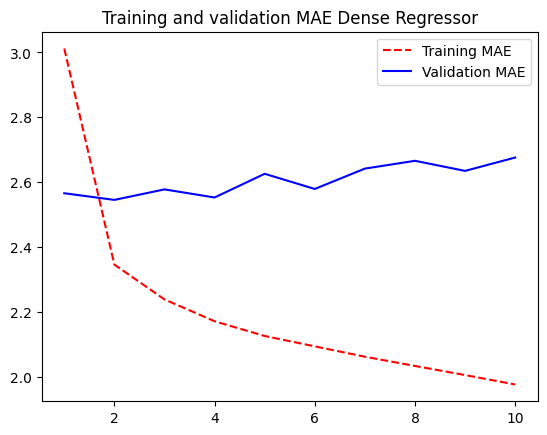

In [16]:
loss = history["mae"]
val_loss = history["val_mae"]
epochs = range(1, len(loss) + 1)
plot_train_val_losses (epochs, loss, val_loss, " Dense Regressor")

In [17]:
#### Let's try a 1D convolutional model


In [ ]:
'''
Superclase del mismo tipo que la anterior. Estructura Conv1d - relu - maxpool1d - relu - maxpool1d - conv1d - relu
reduciendo el tamaño de la ventana de convolucion progresivamente.
Se define una pasada hacia adelante, transponiendo los datos al orden correcto.

Entrena y evalua el modelo. Almacena chackpoints
'''
class ConvRegressor(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(num_features, 8, kernel_size=24),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(8, 8, kernel_size=12),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(8, 8, kernel_size=6),
            nn.ReLU(),
        )
        self.head = nn.Linear(8, 1)

    def forward(self, x):
        x = x.transpose(1, 2)  # (batch, features, steps)
        x = self.features(x)
        x = x.mean(dim=-1)     # global average pooling
        return self.head(x).squeeze(-1)

model = ConvRegressor(raw_data.shape[-1])
model.to(device)
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    checkpoint_path="jena_conv.pt",
)

test_loss, test_mae = evaluate_model(model, test_loader, nn.MSELoss())
print(f"Test MAE: {test_mae:.2f}")


Epoch 1/10 - loss: 26.5627 - mae: 3.9854 - val_loss: 16.0028 - val_mae: 3.1465
Epoch 2/10 - loss: 14.9233 - mae: 3.0698 - val_loss: 15.8213 - val_mae: 3.1279
Epoch 3/10 - loss: 13.7677 - mae: 2.9403 - val_loss: 14.9267 - val_mae: 3.0294
Epoch 4/10 - loss: 12.9913 - mae: 2.8482 - val_loss: 15.1945 - val_mae: 3.0431
Epoch 5/10 - loss: 12.3502 - mae: 2.7739 - val_loss: 14.7438 - val_mae: 2.9898
Epoch 6/10 - loss: 11.8599 - mae: 2.7162 - val_loss: 15.3480 - val_mae: 3.0574
Epoch 7/10 - loss: 11.4586 - mae: 2.6652 - val_loss: 15.1769 - val_mae: 3.0341
Epoch 8/10 - loss: 11.1006 - mae: 2.6232 - val_loss: 14.5505 - val_mae: 2.9645
Epoch 9/10 - loss: 10.8198 - mae: 2.5879 - val_loss: 14.3847 - val_mae: 2.9490
Epoch 10/10 - loss: 10.5436 - mae: 2.5543 - val_loss: 14.3971 - val_mae: 2.9494
Test MAE: 3.18


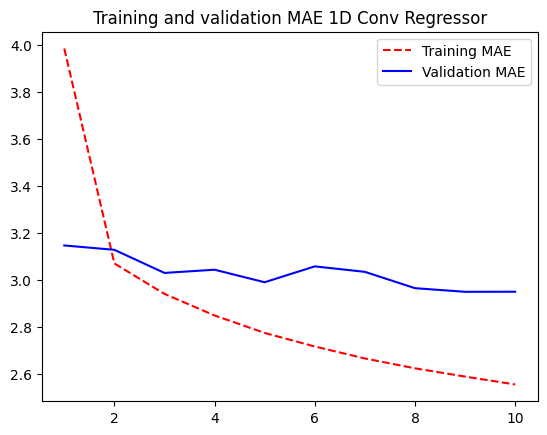

In [22]:
loss = history["mae"]
val_loss = history["val_mae"]
epochs = range(1, len(loss) + 1)
plot_train_val_losses (epochs,loss, val_loss, " 1D Conv Regressor")

### Recurrent neural networks


In [ ]:
''' 
Superclase long short term memory: lstm - lineal
Inicializa hidden state a 16. Define la pasda hacia adelante.

'''
class LSTMRegressor(nn.Module):
    def __init__(self, num_features, hidden_size=16):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]
        return self.fc(x).squeeze(-1)

model = LSTMRegressor(raw_data.shape[-1], hidden_size=16)
model.to(device)
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    checkpoint_path="jena_lstm.pt",
)

test_loss, test_mae = evaluate_model(model, test_loader, nn.MSELoss())
print(f"Test MAE: {test_mae:.2f}")


Epoch 1/10 - loss: 55.5039 - mae: 5.5398 - val_loss: 21.5455 - val_mae: 3.4192
Epoch 2/10 - loss: 16.2124 - mae: 3.0133 - val_loss: 12.2297 - val_mae: 2.6480
Epoch 3/10 - loss: 11.3428 - mae: 2.5864 - val_loss: 10.6054 - val_mae: 2.4927
Epoch 4/10 - loss: 9.8420 - mae: 2.4285 - val_loss: 10.2049 - val_mae: 2.4651
Epoch 5/10 - loss: 9.2351 - mae: 2.3638 - val_loss: 10.1613 - val_mae: 2.4568
Epoch 6/10 - loss: 8.7603 - mae: 2.3083 - val_loss: 10.0514 - val_mae: 2.4455
Epoch 7/10 - loss: 8.4264 - mae: 2.2659 - val_loss: 10.0946 - val_mae: 2.4520
Epoch 8/10 - loss: 8.2922 - mae: 2.2494 - val_loss: 9.8692 - val_mae: 2.4295
Epoch 9/10 - loss: 7.9890 - mae: 2.2080 - val_loss: 10.0892 - val_mae: 2.4548
Epoch 10/10 - loss: 7.8034 - mae: 2.1808 - val_loss: 10.1644 - val_mae: 2.4705
Test MAE: 2.60


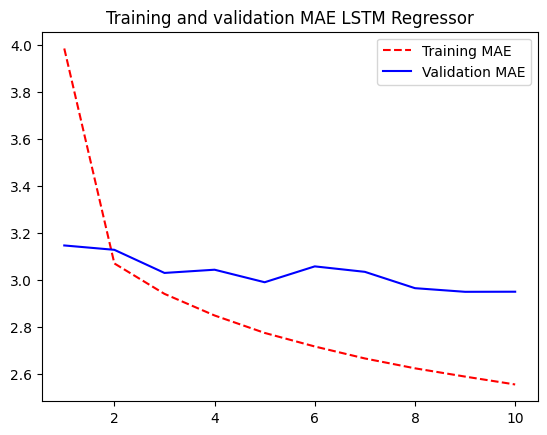

In [21]:
loss = history["mae"]
val_loss = history["val_mae"]
epochs = range(1, len(loss) + 1)
plot_train_val_losses (epochs,loss, val_loss, " LSTM Regressor")

#### Using recurrent dropout to fight overfitting


In [ ]:
''' 
Superclase long short term memory implementando dropout (prefijado al 50 %) para evitar overfitting. lstm - dropout - fc
Toma el numero de features, hidden state y valor de dropout.
Define la pasada hacia adelante, llevando a cabo el dropout en el orden indicado al inicio.
'''
class LSTMWithDropoutRegressor(nn.Module):
    def __init__(self, num_features, hidden_size=32, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        x = self.dropout(h_n[-1])
        return self.fc(x).squeeze(-1)

model = LSTMWithDropoutRegressor(raw_data.shape[-1], hidden_size=32, dropout=0.5)
model.to(device)
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    checkpoint_path="jena_lstm_dropout.pt",
)

test_loss, test_mae = evaluate_model(model, test_loader, nn.MSELoss())
print(f"Test MAE: {test_mae:.2f}")

Epoch 1/50 - loss: 42.3312 - mae: 4.7530 - val_loss: 13.0220 - val_mae: 2.7126
Epoch 2/50 - loss: 16.5201 - mae: 3.1263 - val_loss: 9.8971 - val_mae: 2.4173
Epoch 3/50 - loss: 14.5779 - mae: 2.9516 - val_loss: 9.3128 - val_mae: 2.3730
Epoch 4/50 - loss: 13.7447 - mae: 2.8636 - val_loss: 9.5769 - val_mae: 2.4182
Epoch 5/50 - loss: 13.1493 - mae: 2.8052 - val_loss: 8.7950 - val_mae: 2.3064
Epoch 6/50 - loss: 12.5027 - mae: 2.7334 - val_loss: 8.9363 - val_mae: 2.3329
Epoch 7/50 - loss: 12.0220 - mae: 2.6871 - val_loss: 9.1467 - val_mae: 2.3756
Epoch 8/50 - loss: 11.7755 - mae: 2.6582 - val_loss: 9.5777 - val_mae: 2.4258
Epoch 9/50 - loss: 11.2623 - mae: 2.6028 - val_loss: 9.3228 - val_mae: 2.4008
Epoch 10/50 - loss: 10.9887 - mae: 2.5700 - val_loss: 9.4988 - val_mae: 2.4260
Epoch 11/50 - loss: 10.7239 - mae: 2.5396 - val_loss: 9.7170 - val_mae: 2.4469
Epoch 12/50 - loss: 10.4622 - mae: 2.5048 - val_loss: 9.7692 - val_mae: 2.4547
Epoch 13/50 - loss: 10.3211 - mae: 2.4879 - val_loss: 9.6057

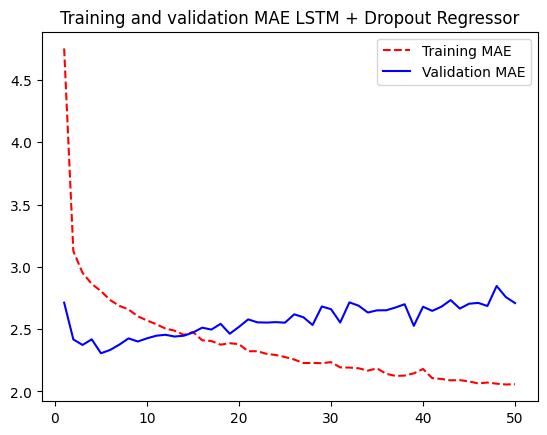

In [25]:
loss = history["mae"]
val_loss = history["val_mae"]
epochs = range(1, len(loss) + 1)
plot_train_val_losses (epochs,loss, val_loss, " LSTM + Dropout Regressor")

#### Stacking recurrent layers


In [ ]:
''' 
Superclase GRU para mejorar el rendimiento de lstm manteniendo dropout. 2 capas prefijadas.
'''
class StackedGRURegressor(nn.Module):
    def __init__(self, num_features, hidden_size=32, dropout=0.5):
        super().__init__()
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        x = self.dropout(h_n[-1])
        return self.fc(x).squeeze(-1)

model = StackedGRURegressor(raw_data.shape[-1], hidden_size=32, dropout=0.5)
model.to(device)
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    checkpoint_path="jena_stacked_gru_dropout.pt",
)

test_loss, test_mae = evaluate_model(model, test_loader, nn.MSELoss())
print(f"Test MAE: {test_mae:.2f}")


Epoch 1/50 - loss: 39.6848 - mae: 4.5768 - val_loss: 13.3157 - val_mae: 2.7087
Epoch 2/50 - loss: 15.5516 - mae: 3.0305 - val_loss: 10.4042 - val_mae: 2.4681
Epoch 3/50 - loss: 13.9358 - mae: 2.8848 - val_loss: 10.3781 - val_mae: 2.4954
Epoch 4/50 - loss: 12.9136 - mae: 2.7841 - val_loss: 9.9808 - val_mae: 2.4477
Epoch 5/50 - loss: 12.2466 - mae: 2.7132 - val_loss: 9.7338 - val_mae: 2.4189
Epoch 6/50 - loss: 11.6016 - mae: 2.6436 - val_loss: 10.6981 - val_mae: 2.5524
Epoch 7/50 - loss: 10.9731 - mae: 2.5689 - val_loss: 10.5830 - val_mae: 2.5357
Epoch 8/50 - loss: 10.5512 - mae: 2.5227 - val_loss: 10.8999 - val_mae: 2.5664
Epoch 9/50 - loss: 10.0099 - mae: 2.4560 - val_loss: 11.5841 - val_mae: 2.6613
Epoch 10/50 - loss: 9.5732 - mae: 2.4039 - val_loss: 11.4820 - val_mae: 2.6354
Epoch 11/50 - loss: 9.1772 - mae: 2.3510 - val_loss: 11.2235 - val_mae: 2.5926
Epoch 12/50 - loss: 8.8221 - mae: 2.3051 - val_loss: 11.7671 - val_mae: 2.6634
Epoch 13/50 - loss: 8.5045 - mae: 2.2613 - val_loss: 1

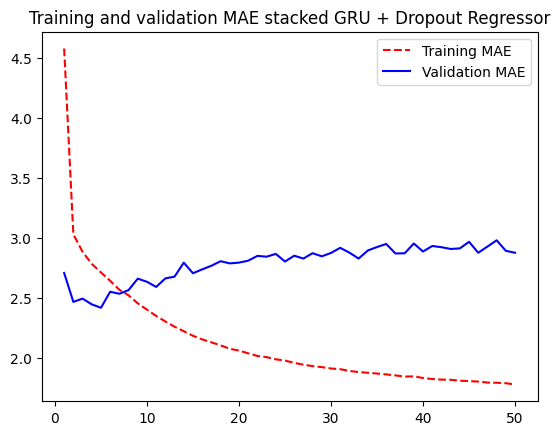

In [27]:
loss = history["mae"]
val_loss = history["val_mae"]
epochs = range(1, len(loss) + 1)
plot_train_val_losses (epochs,loss, val_loss, " stacked GRU + Dropout Regressor")

#### Using bidirectional RNNs


In [28]:
class BidirectionalLSTMRegressor(nn.Module):
    def __init__(self, num_features, hidden_size=16):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        x = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.fc(x).squeeze(-1)

model = BidirectionalLSTMRegressor(raw_data.shape[-1], hidden_size=16)
model.to(device)
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
)

test_loss, test_mae = evaluate_model(model, test_loader, nn.MSELoss())
print(f"Test MAE: {test_mae:.2f}")


Epoch 1/10 - loss: 38.5648 - mae: 4.4780 - val_loss: 14.5466 - val_mae: 2.9338
Epoch 2/10 - loss: 11.8983 - mae: 2.6778 - val_loss: 11.6952 - val_mae: 2.6420
Epoch 3/10 - loss: 10.0051 - mae: 2.4643 - val_loss: 10.7000 - val_mae: 2.5312
Epoch 4/10 - loss: 9.4086 - mae: 2.3818 - val_loss: 10.2398 - val_mae: 2.4746
Epoch 5/10 - loss: 8.8713 - mae: 2.3142 - val_loss: 10.1020 - val_mae: 2.4550
Epoch 6/10 - loss: 8.7693 - mae: 2.2971 - val_loss: 10.0079 - val_mae: 2.4488
Epoch 7/10 - loss: 8.2523 - mae: 2.2340 - val_loss: 9.8837 - val_mae: 2.4340
Epoch 8/10 - loss: 8.0939 - mae: 2.2188 - val_loss: 10.0543 - val_mae: 2.4524
Epoch 9/10 - loss: 7.7854 - mae: 2.1759 - val_loss: 10.1891 - val_mae: 2.4666
Epoch 10/10 - loss: 7.5739 - mae: 2.1450 - val_loss: 9.9100 - val_mae: 2.4362
Test MAE: 2.57


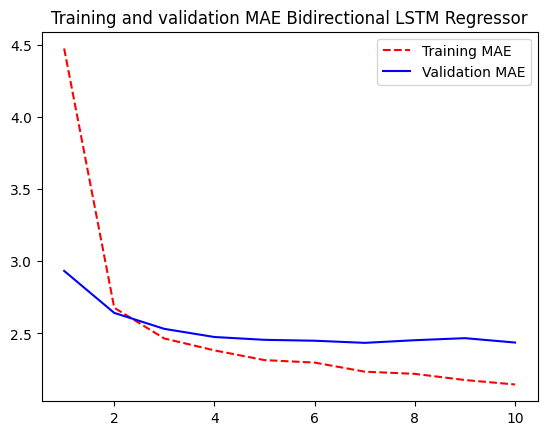

In [29]:
loss = history["mae"]
val_loss = history["val_mae"]
epochs = range(1, len(loss) + 1)
plot_train_val_losses (epochs,loss, val_loss, " Bidirectional LSTM Regressor")